5350 Thesis in Economics

Andres Cruz 25199 & Klara Holmer 25037 

Code for Grundskola - Compulsory School 

In [1]:
# Importing Libraries
import numpy as np 
import pandas as pd 
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns

Grundskola - Slutbetyg per ämne årskurs 9, fr.o.m. 2012/13 till 2021/22

"De här statistikuppgifterna visar slutbetyg i respektive ämne i årskurs 9, vårterminen"

- Excel filerna är ordnade efter vårterminens år

In [2]:
# Step 1  -  Creating DataFrames for each specific subject for Grundskolan 

# Define the folder path
path = r'/Users/andrescruz/Documents/Handelshögskolan/MSc Economic/Semester 4/5350 Thesis in Economics/Raw Data/Skolverket Data/grundskola_I'

# Get all Excel files in the folder
all_files = glob.glob(os.path.join(path, "*.xlsx"))

# Sort the files alphabetically
all_files.sort()

# Predefined list of years (ensure this list matches the number of files and in the right order of how python reads the folder (ascending or descending))
ACADEMIC_YEAR = ['2014/15', '2015/16', '2016/17','2017/18', '2018/19', '2019/20', '2020/21', '2021/22']

# Defining a function
def read_excel_files(sheet_name):

    """""
    This function reads each excel file from the specified path and sheet, modifies the dataframes, and then creates a concatenated DataFrame

    Parameters:
    - sheet_name: specify which subject to read (in swedish) at the end of this chunk
    """""

    # Create an empty list to store DataFrames
    li = []
    
    # A for loop
    for i, filename in enumerate(all_files):

        if i == 0:
            # For the first file, read without skipping rows to extract the header row 
            temp_df = pd.read_excel(filename, sheet_name=sheet_name, header = None)
            # Extract column names from the row index 10, which is from Pandas DataFrame positioning
            column_names = temp_df.iloc[10].tolist()
            # Now read the data skipping the first 11 rows, which is from the Excel file positioning
            df = pd.read_excel(filename, sheet_name=sheet_name, header=None, skiprows = 11)
            # Assign the extracted column names
            df.columns = column_names
        else:
            # For subsequent files, read without skipping rows to locate the matching row
            temp_df = pd.read_excel(filename, sheet_name=sheet_name, header=None)
            # Locate the row number where the column names match
            column_names_row = temp_df.apply(lambda row: row.tolist() == column_names, axis=1).idxmax()
            # Read the data, skipping rows up to the matching row
            df = pd.read_excel(filename, sheet_name=sheet_name, header=None, skiprows=column_names_row + 1)
            # Assign the extracted column names
            df.columns = column_names

        # Add the "academic_year" column using the predefined years list
        df["academic_year"] = ACADEMIC_YEAR[i]
        # Add the "educational_stage" column with a fixed value
        df["educational_stage"] = 'grundskola'
        
        # Append the DataFrame to the list
        li.append(df)
    
    return pd.concat(li, ignore_index=True)

# --- Specify which subjects (i.e., which sheet names) to read ---
DataFrame_I_English = read_excel_files('Engelska')
DataFrame_I_Mathematics = read_excel_files('Matematik')
DataFrame_I_Swedish = read_excel_files('Svenska')

# List of DataFrames 
dataframes = [DataFrame_I_English, DataFrame_I_Mathematics, DataFrame_I_Swedish]

In [3]:
# Step 2 - Modification - Changing Column Names

# For Loop to iterate over my list, and changing the names
for df in dataframes:

    # Define a list of new column names in the correct order
    new_names = [
    'school_name',                      # Column 1 Skola
    'school_ID',                        # Column 2 Skol-enhetskod
    'school_municipality',              # Column 3 Skolkommun
    'municipality_ID',                  # Column 4 Kommun-kod
    'type_of_ownership',                # Column 5 Typ av huvudman
    'owner',                            # Column 6 Huvudman
    'owner_orgnr',                      # Column 7 Huvudman orgnr
    'graduating_students',              # Column 8 Antal elever Totalt År 9
    'total_female_students',            # Column 9 Antal elever Flickor
    'total_male_students',              # Column 10 Antal elever Pojkar
    'average_grade_points',             # Column 11 Totalt	Betygspoäng (Genomsnittligt) ONLY FOR THE SPECIFIC SUBJECT
    'share_students_A_E',               # Column 12 Totalt	Andel (%) med A-E
    'female_average_grade_points',      # Column 13 Flickor	Betygspoäng
    'share_female_students_A_E',        # Column 14 Flickor	Andel (%) med A-E
    'male_average_grade_points',        # Column 15 Pojkar Betygspoäng
    'share_male_students_A_E',          # Column 16 Pojkar Andel (%) med A-E
    'academic_year',                    # Column 17 läsår
    'educational_stage'                 # Column 18 skolform
    ]

    # Assign the new column names based on position
    df.columns = new_names

    # Define the list of columns to drop
    columns_to_drop = [
    'school_name', 'owner', 'owner_orgnr', 'total_female_students', 'total_male_students',
    'female_average_grade_points', 'share_female_students_A_E', 'male_average_grade_points', 'share_male_students_A_E', 'average_grade_points', 'graduating_students'
    ]

    # drop the specified columns
    df.drop(columns=columns_to_drop, axis=1, inplace=True)

# Rename share_students_A_E to subject-specific names

# Rename share_students_A_E column to subject-specific name
DataFrame_I_English.rename(columns={'share_students_A_E': 'share_students_A_E_eng'}, inplace=True)
DataFrame_I_Swedish.rename(columns={'share_students_A_E': 'share_students_A_E_sv'}, inplace=True)
DataFrame_I_Mathematics.rename(columns={'share_students_A_E': 'share_students_A_E_ma'}, inplace=True)

In [4]:
# Step 4 - Merge DataFrames: Only schools existing in all three DataFrames

# Define the keys for merging (you want to merge by school identity and year and stage)
merge_keys = ['school_ID', 'school_municipality', 'municipality_ID', 'type_of_ownership', 'academic_year', 'educational_stage']

# First merge English and Swedish
DataFrame_I = pd.merge(
    DataFrame_I_English,
    DataFrame_I_Swedish,
    on=merge_keys,
    how='inner'  # inner join to keep only matching schools
)

# Then merge the result with Mathematics
DataFrame_I = pd.merge(
    DataFrame_I,
    DataFrame_I_Mathematics,
    on=merge_keys,
    how='inner'  # inner join again
)

# Define the desired column order
column_order = [
    'school_ID', 'school_municipality', 'municipality_ID', 'type_of_ownership', 'academic_year', 'educational_stage',
    'share_students_A_E_eng', 'share_students_A_E_ma', 'share_students_A_E_sv']

# Reorder the DataFrame
DataFrame_I = DataFrame_I[column_order]

Grundskola - Antal elever per årskurs 2012/13 till 2021/22 Skolenhet

"Uppgifterna avser oktober det valda året."

- Höstterminens år används i namnen på excel filerna
- Därav så ändrar vi manuellt till vårterminens år för att matcha korrekt med andra DataFrames
- Antagande att 'Antal Elever' är detsamma på höst- och vårterminen

In [5]:
# Step 1 - Antal Elever Grundskola - Creating Dataframe 

# Setting the path
path = r'/Users/andrescruz/Documents/Handelshögskolan/MSc Economic/Semester 4/5350 Thesis in Economics/Raw Data/Skolverket Data/grundskola_II'

# Get all Excel files in the folder
all_files = glob.glob(os.path.join(path, "*.xlsx"))

# Sort the files (ascending by default)
all_files.sort()

# Predefined list of LÄSÅR (ensure this list matches the number of files and in the right order of how python reads the folder (ascending or descending))
ACADEMIC_YEAR = ['2014/15', '2015/16', '2016/17','2017/18', '2018/19', '2019/20', '2020/21', '2021/22']

# Creating a function
def read_excel_files(sheet_name):

    """""
    This function reads each excel file from the specified path and sheet, modifies the dataframes, and then creates a concatenated DataFrame

    Parameters:
    - sheet_name: Only sheet_name to read is Statistik
    """""

    # Create an empty list to store DataFrames
    li = []
    
    # A for loop
    for i, filename in enumerate(all_files):
        
        if i == 0:
            # For the first file, read without skipping rows to extract the header row 
            temp_df = pd.read_excel(filename, sheet_name=sheet_name, header=None)
            # Extract column names from row index 6, Pandas DataFrame positioning
            column_names = temp_df.iloc[6].tolist()
            # Now read the data, skipping the first 7 rows from the Excel File
            df = pd.read_excel(filename, sheet_name=sheet_name, header=None, skiprows=7)
            # Assign the extracted column names
            df.columns = column_names
        else:
            # For subsequent files, read without skipping rows to locate the matching row
            temp_df = pd.read_excel(filename, sheet_name=sheet_name, header=None)
            # Locate the row number where the column names match
            column_names_row = temp_df.apply(lambda row: row.tolist() == column_names, axis=1).idxmax()
            # Read the data, skipping rows up to the matching row 
            df = pd.read_excel(filename, sheet_name=sheet_name, header=None, skiprows=column_names_row + 1) # adding 1 since Excel start from index/row 1
            # Assign the extracted column names
            df.columns = column_names

        # Add the "academic_year" column using the predefined years list
        df["academic_year"] = ACADEMIC_YEAR[i]

        # Add the "educational_stage" column with the fixed value 
        df["educational_stage"] = 'grundskola' 

        # Append the DataFrame to the list
        li.append(df)
    
    return pd.concat(li, ignore_index=True)

# Creating DataFrame_II by using the function created 
DataFrame_II = read_excel_files('Statistik')

In [6]:
# Step 2 - Changing column names and dropping columns that will not be used

# Define a list of new column names in the correct order
# Column names for column number 10, 11, 12, and 13 are matched with Gymnasieskola DataFrames column names
new_names = [
    'school_name',                                             # Column 1 Skola 
    'school_ID',                                               # Column 2 Skol-enhetskod 
    'school_municipality',                                     # Column 3 Skolkommun 
    'municipality_ID',                                         # Column 4 Kommun-kod 
    'type_of_ownership',                                       # Column 5 Typ av huvudman 
    'owner',                                                   # Column 6 Huvudman
    'owner_orgnr',                                             # Column 7 Huvudman orgnr
    'student_nursery_school',                                  # Column 8 Elever, förskoleklass
    'share_female_students_nursery_school',                    # Column 9 Andel (%) flickor, förskoleklass
    'total_school_students',                                   # * Column 10 Elever, årskurs 1-9 
    'share_female_students',                                   # * Column 11 Andel (%) flickor, årskurs 1-9 
    'share_foreign_background',                                # * Column 12 Andel (%) elever med utländsk bakgrund, åk 1-9   
    'share_postsecondary_parents',                             # * Column 13 Andel (%) elever med föräldrar med eftergymnasial utb., åk 1-9   
    'students_year1',                                          # Column 14 Elever, årskurs 1
    'students_year2',                                          # Column 15 Elever, årskurs 2
    'students_year3',                                          # Column 16 Elever, årskurs 3
    'students_year4',                                          # Column 17 Elever, årskurs 4
    'students_year5',                                          # Column 18 Elever, årskurs 5
    'students_year6',                                          # Column 19 Elever, årskurs 6
    'students_year7',                                          # Column 20 Elever, årskurs 7
    'students_year8',                                          # Column 21 Elever, årskurs 8
    'students_year9',                                          # Column 22 Elever, årskurs 9
    'academic_year',                                           # Column 23 läsår
    'educational_stage'                                        # Column 24 skolform
    ]

# Applying the new names 
DataFrame_II.columns = new_names

# Define the list of columns to drop
columns_to_drop = ['school_name', 
                   'owner', 
                   'owner_orgnr',
                   'student_nursery_school', 
                   'share_female_students_nursery_school', 
                   'students_year1',                                         
                   'students_year2',            
                   'students_year3',                                          
                   'students_year4',                                          
                   'students_year5',     
                   'students_year6',                                         
                   'students_year7',            
                   'students_year8',                                          
                   'students_year9']

# Drop the specified columns
DataFrame_II.drop(columns=columns_to_drop, axis=1, inplace=True)

# Define the desired column order
column_order = ['school_ID', 'school_municipality', 'municipality_ID', 'type_of_ownership', 'academic_year', 'educational_stage',
                'total_school_students',
                'share_female_students', 'share_foreign_background', 'share_postsecondary_parents']

# Reorder the DataFrame
DataFrame_II = DataFrame_II[column_order]

Grundskola - Personalstatistik med lärarlegitimation och behörighet 2014/15 till 2021/22

"Statistiken avser anställda den 15 oktober valt läsår."

- Höstterminens år används i namnen på excel filerna
- Därav så ändrar vi manuellt till vårterminens år för att matcha korrekt med andra DataFrames
- Antagande att 'Personalstatistik med lärarlegitimation och behörighet' är detsamma på höst- och vårterminen

In [7]:
# Step 1 - Creating Dataframe

# Setting path
path = r'/Users/andrescruz/Documents/Handelshögskolan/MSc Economic/Semester 4/5350 Thesis in Economics/Raw Data/Skolverket Data/grundskola_III'

# Get all Excel files in the folder
all_files = glob.glob(os.path.join(path, "*.xlsx"))

# Sort the files (ascending by default)
all_files.sort()

# Predefined list of years (ensure this list matches the number of files and in the right order of how python reads the folder (ascending or descending))
ACADEMIC_YEAR = ['2014/15', '2015/16', '2016/17','2017/18', '2018/19', '2019/20', '2020/21', '2021/22']

# Defining a function 
def read_excel_files(sheet_name):

    """""
    This function reads each excel file from the specified path and sheet, modifies the dataframes, and then creates a concatenated DataFrame

    Parameters:
    - sheet_name: specify which sheet_name to read
    """""

    # Create an empty list to store DataFrames
    li = []
    
    # A for loop
    for i, filename in enumerate(all_files):
        
        if i == 0:
            # For the first file, read without skipping rows to extract the header row 
            temp_df = pd.read_excel(filename, sheet_name=sheet_name, header=None)
            # Extract column names from row index 9, Pandas DataFrame positioning
            column_names = temp_df.iloc[8].tolist()
            # Now read the data, skipping the first 10 rows from the Excel File
            df = pd.read_excel(filename, sheet_name=sheet_name, header=None, skiprows=9)
            # Assign the extracted column names
            df.columns = column_names
        else:
            # For subsequent files, read without skipping rows to locate the matching row
            temp_df = pd.read_excel(filename, sheet_name=sheet_name, header=None)
            # Locate the row number where the column names match
            column_names_row = temp_df.apply(lambda row: row.tolist() == column_names, axis=1).idxmax()
            # Read the data, skipping rows up to the matching row 
            df = pd.read_excel(filename, sheet_name=sheet_name, header=None, skiprows=column_names_row + 1) # adding 1 since Excel start from index/row 1
            # Assign the extracted column names
            df.columns = column_names

        # Add the "academic_year" column using the predefined years list
        df["academic_year"] = ACADEMIC_YEAR[i]

        # Add the "educational_stage" column with the fixed value 'grundskola'
        df["educational_stage"] = 'grundskola'

        # Append the DataFrame to the list
        li.append(df)
    
    return pd.concat(li, ignore_index=True)

# Applying the function to each specific program
DataFrame_III = read_excel_files('Statistik')

In [8]:
# Step 2  - Renaming columns and dropping columns

# Define a list of new column names in the correct order
new_column_names = [
    'school_name',                                            # Column 1 'Skola'
    'school_ID',                                              # Column 2 'Skol-enhetskod'
    'school_municipality',                                    # Column 3 'Skolkommun'
    'municipality_ID',                                        # Column 4 'Kommun-kod'
    'type_of_ownership',                                      # Column 5 'Typ av huvudman'
    'owner',                                                  # Column 6 'Huvudman'
    'owner_orgnr',                                            # Column 7 'Huvudman orgnr'
    'total_fulltime_teachers',                                # Column 8 'Heltidstjänster Totalt antal'
    'total_fulltime_certified_teachers',                      # Column 9 'Heltidstjänster Antal med lärarlegitimation och behörighet'
    'share_fulltime_certified_teachers',                      # Column 10 'Heltidstjänster Andel med lärarlegitimation och behörighet'
    'heltid_förstelärare',                                    # Column 11 'Heltidstjänster Förstelärare'
    'total_active_teachers',                                  # Column 12 'Tjänstgörande lärare Totalt antal '
    'total_active_certified_teachers',                        # Column 13 'Tjänstgörande lärare Antal med lärarlegitimation och behörighet i minst ett ämne'
    'share_active_certified_teachers',                        # Column 14 'Tjänstgörande lärare Andel med lärarlegitimation och behörighet i minst ett ämne'
    'tjänst_förstelärare',                                    # Column 15 'Tjänstgörande lärare Förstelärare '
    'academic_year',                                          # Column 16 'läsår'
    'educational_stage'                                       # Column 17 'skolform'
    ]

# Define a list of columns to drop
columns_to_drop = [
    'school_name',                                            # Column 1 'Skola'
    'owner',                                                  # Column 6 'Huvudman'
    'owner_orgnr',                                            # Column 7 'Huvudman orgnr'
    'heltid_förstelärare',                                    # Column 11 'Heltidstjänster Förstelärare'
    'tjänst_förstelärare',                                    # Column 15 'Tjänstgörande lärare Förstelärare '
    ]

# Define the desired column order
column_order = ['school_ID', 'school_municipality', 'municipality_ID', 'type_of_ownership', 'academic_year', 'educational_stage',
                'total_fulltime_teachers', 'total_fulltime_certified_teachers', 'share_fulltime_certified_teachers',            
                'total_active_teachers', 'total_active_certified_teachers', 'share_active_certified_teachers']  

# Assigning new column names
DataFrame_III.columns = new_column_names 

# Dropping columns which will not be used
DataFrame_III.drop(columns=columns_to_drop, axis=1, inplace=True)

# Reorder the DataFrame
DataFrame_III = DataFrame_III[column_order]

Grundskola - Slutbetyg årskurs 9, samtliga elever läsår 2014/15 till 2021/22

"Samtliga uppgifter utom totalen för antal elever, avser elever med betyg enligt det mål- och kunskapsrelaterade betygssystemet. Uppgifterna avser betyg före prövning."

- Spring semester year is used in the name of the ExcelFiles

In [9]:
# Step 1 - Slutbetyg årskurs 9 Grundskola - Creating Dataframe 

# Defining Path 
path = r'/Users/andrescruz/Documents/Handelshögskolan/MSc Economic/Semester 4/5350 Thesis in Economics/Raw Data/Skolverket Data/grundskola_IIII'

# Get all Excel files in the folder
all_files = glob.glob(os.path.join(path, "*.xlsx"))

# Sort the files (ascending by default)
all_files.sort()

# Predefined list of LÄSÅR (ensure this list matches the number of files and in the right order of how python reads the folder (ascending or descending))
ACADEMIC_YEAR = ['2014/15', '2015/16', '2016/17','2017/18', '2018/19', '2019/20', '2020/21', '2021/22']

# Creating a function
def read_excel_files(sheet_name):

    """""
    This function reads each excel file from the specified path and sheet, modifies the dataframes, and then creates a concatenated DataFrame

    Parameters:
    - sheet_name: specify (at the end of this chunk) which sheet_name to read 
    """""

    # Create an empty list to store DataFrames
    li = []
    
    # A for loop
    for i, filename in enumerate(all_files):
        
        if i == 0:
            # For the first file, read without skipping rows to extract the header row 
            temp_df = pd.read_excel(filename, sheet_name=sheet_name, header=None)
            # Extract column names from row index in Pandas DataFrame positioning
            column_names = temp_df.iloc[6].tolist()
            # Now read the data, skipping the first rows 7 (6+1 for excel file indexing) from the Excel File, 
            df = pd.read_excel(filename, sheet_name=sheet_name, header=None, skiprows=7)
            # Assign the extracted column names
            df.columns = column_names
        else:
            # For subsequent files, read without skipping rows to locate the matching row
            temp_df = pd.read_excel(filename, sheet_name=sheet_name, header=None)
            # Locate the row number where the column names match
            column_names_row = temp_df.apply(lambda row: row.tolist() == column_names, axis=1).idxmax()
            # Read the data, skipping rows up to the matching row 
            df = pd.read_excel(filename, sheet_name=sheet_name, header=None, skiprows=column_names_row + 1) # adding 1 since Excel start from index/row 1
            # Assign the extracted column names
            df.columns = column_names

        # Add the "läsår_vår" column using the predefined years list
        df["academic_year"] = ACADEMIC_YEAR[i]

        # Add the "educational_stage" column with the fixed value 'lower secondary school'
        df["educational_stage"] = 'grundskola'

        # Append the DataFrame to the list
        li.append(df)
    
    return pd.concat(li, ignore_index=True)

# --- Specify sheet name choice ---
sheet_name_choice = "Statistik"

# Applying the function
DataFrame_IIII = read_excel_files(sheet_name_choice)

print(DataFrame_IIII)

                             Skola  Skol-enhetskod  Skolkommun  Kommun-kod  \
0              Ahlafors Fria skola        71387206         Ale        1440   
1                  Aroseniusskolan        48529699         Ale        1440   
2                      Bohusskolan        11043800         Ale        1440   
3                   Da Vinciskolan        61084420         Ale        1440   
4              Gustav Adolfsskolan        74064638    Alingsås        1489   
...                            ...             ...         ...         ...   
13386                 Strandskolan        50308658   Överkalix        2513   
13387           Överkalix Friskola        13342436   Överkalix        2513   
13388  Hietaniemi Friskoleförening        46252858  Övertorneå        2518   
13389    Svanstein skola Diamanten        90707437  Övertorneå        2518   
13390        Svarträvens skola 4-9        18991431  Övertorneå        2518   

      Typ av huvudman                                Huvudman  

In [10]:
# Step 2 - Modifying DataFrame_IIII

# Define a list of new column names in the correct order
new_names = [
    'school_name',                                  # Column 1: from 'Skola'
    'school_ID',                                    # Column 2: from 'Skol-enhetskod'
    'school_municipality',                          # Column 3: from 'Skolkommun'
    'municipality_ID',                              # Column 4: from 'Kommun-kod'
    'type_of_ownership',                            # Column 5: from 'Typ av huvudman'
    'owner',                                        # Column 6: from 'Huvudman'
    'owner_orgnr',                                  # Column 7: from 'Huvudman orgnr'
    'graduating_students',                          # Column 8: from 'Antal elever' 
    'andel_uppnått_kunskapskraven_i_alla_ämnen',    # Column 9: Andel som uppnått kunskapskraven i alla ämnen
    'andel_%_elever_behöriga_yrkesprog.',           # Column 10: Andel (%) elever behöriga till yrkesprog.
    'graduates_average_grade_points',               # Column 11: Genomsnittligt meritvärde (17 ämnen)
    'academic_year',                                # Column 12: from 'läsår'
    'educational_stage'                             # Column 13: from 'skolform'
    ]

# Assign the new column names based on their position
DataFrame_IIII.columns = new_names

# Define a list of columns to drop
columns_to_drop = [
    'school_name',                                           
    'owner',                                                  
    'owner_orgnr',  
    'andel_uppnått_kunskapskraven_i_alla_ämnen',                                    
    'andel_%_elever_behöriga_yrkesprog.',                                    
    ]

# Dropping columns which not be used 
DataFrame_IIII.drop(columns=columns_to_drop, axis=1, inplace=True)

# Define the desired column order
column_order = [
    'school_ID', 'school_municipality', 'municipality_ID', 'type_of_ownership', 'academic_year', 'educational_stage',
    'graduating_students', 'graduates_average_grade_points']

# Reorder the DataFrame
DataFrame_IIII = DataFrame_IIII[column_order]

Grundskola - Combining DataFrames

DataFrame_I - Slutbetyg per ämne årskurs 9, fr.o.m. 2012/13 till 2021/22
- DataFrame_I_English
- grundskola_I_Mathematics
- grundskola_I_Swedish

DataFrame_II - Antal elever per årskurs 2012/13 till 2021/22 Skolenhet

DataFrame_III - Personalstatistik med lärarlegitimation och behörighet 2014/15 till 2021/22

DataFrame_IIII - Slutbetyg årskurs 9, samtliga elever läsår 2014/15 till 2021/22

In [11]:
# --- Step 1 Merging DataFrames --- 

# https://www.geeksforgeeks.org/different-types-of-joins-in-pandas/
# Using LEFT JOIN
# Grundskola_I <- Grundskola_II  
# Grundskola_I <- Grundskola_III
# Grundskola_I <- Grundskola_IIII


# Define the join keys (columns that will NOT receive suffixes)
join_keys = ['school_ID', 'school_municipality', 'municipality_ID', 'type_of_ownership', 'academic_year', 'educational_stage']

# Merge the first two DataFrames with an left join and custom suffixes:
DataFrame = pd.merge(
    DataFrame_I,
    DataFrame_II, 
    on = join_keys,
    how = 'left')

# Merge the first two DataFrames with an inner join and custom suffixes:
DataFrame = pd.merge(
    DataFrame,
    DataFrame_III, 
    on = join_keys,
    how = 'left')

# Merge the first two DataFrames with an inner join and custom suffixes:
DataFrame = pd.merge(
    DataFrame,
    DataFrame_IIII, 
    on = join_keys,
    how = 'left')

# Some school only existed in DataFrame_I, but not in Dataframe_II, and Dataframe_III 
# Therefore missing values were added from those in each specific volumn
# I manually add one dot to those observations 

# Replace all missing (NaN) values with a dot "."
# First, add "." to categories where needed
for col in DataFrame.select_dtypes(include='category').columns:
    if '.' not in DataFrame[col].cat.categories:
        DataFrame[col] = DataFrame[col].cat.add_categories('.')

# Now it is safe to fill missing values
DataFrame = DataFrame.fillna('.')

# Excluding academic year 2021/22
DataFrame = DataFrame[DataFrame['academic_year'] != '2021/22']

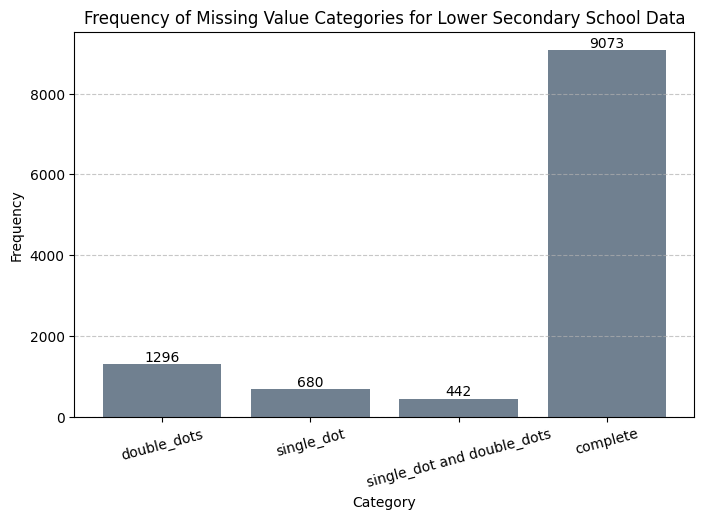

/var/folders/dk/hpy2mtkd7sq6_2c3125100b80000gn/T/ipykernel_10253/3606553318.py:106: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  bottom[i] + height / 2,


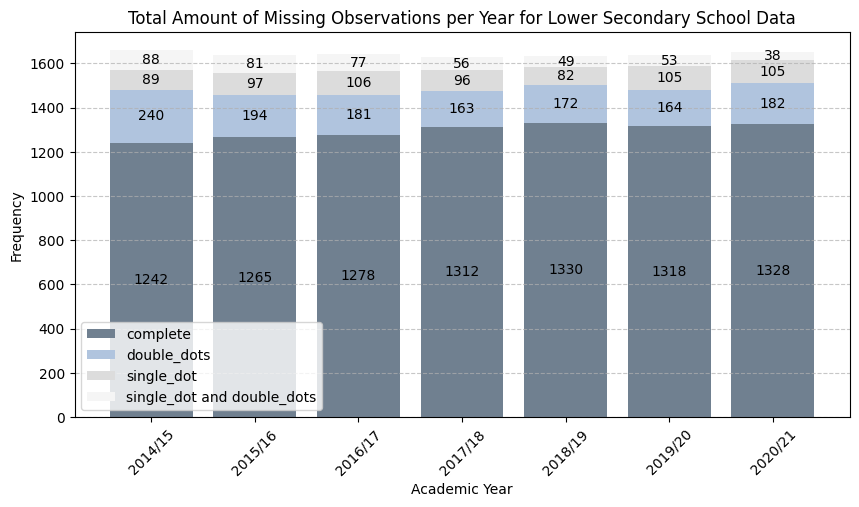

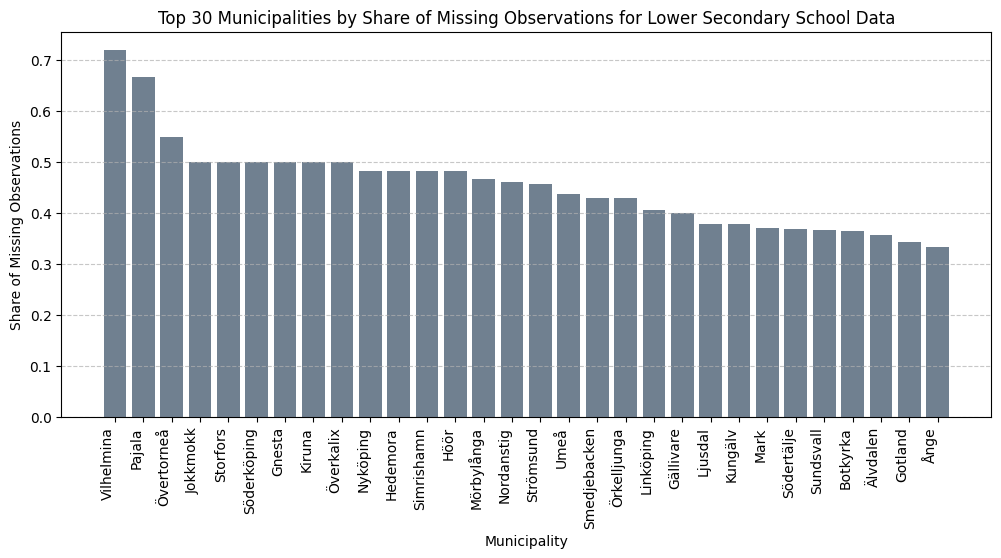

In [12]:
# --- Step 2 Missing Data & Censorship  ---

"""
Om resultatuppgiften baseras på färre än 10 elever, dubbelprickas den. 
Då visas två prickar (..)  istället för utfall. 
Om data saknas visas en prick (.) istället för utfall.
"""

# --- Plot 1: Frequency of Missing Value Categories ---

# Function to classify rows based on presence of '.' and '..'
def classify_missing_rows(row):
    contains_single_dot = (row == '.').any()
    contains_double_dot = (row == '..').any()

    if contains_single_dot and contains_double_dot:
        return "single_dot and double_dots"
    elif contains_double_dot:
        return "double_dots"
    elif contains_single_dot:
        return "single_dot"
    else:
        return "complete"

# Apply classification to the DataFrame
DataFrame["missing_data"] = DataFrame.apply(classify_missing_rows, axis=1)

# Define all possible category labels to ensure they appear in the plot
all_categories = ["double_dots", "single_dot", "single_dot and double_dots", "complete"]

# Count occurrences of each category and reindex to include all categories
category_counts = DataFrame['missing_data'].value_counts().reindex(all_categories, fill_value=0)

# Plot the frequency of each category
plt.figure(figsize=(8, 5))
bars = plt.bar(category_counts.index, category_counts.values, color='slategrey')

# Add count annotations to each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f'{int(height)}', ha='center', va='bottom')

# Formatting
plt.xlabel("Category")
plt.ylabel("Frequency")
plt.title(f"Frequency of Missing Value Categories for Lower Secondary School Data")
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Save and Show plot
plt.savefig('/Users/andrescruz/Documents/Handelshögskolan/MSc Economic/Semester 4/5350 Thesis in Economics/Output/Data Preparation/missing_value_categories_grundskola.png', dpi=300, bbox_inches='tight')
plt.show()

# --- Plot 2: Total Amount of Missing Observations per Year ---

# Function to filter rows that contain missing indicators or 'complete'
def filter_missing_rows(df):
    return df[df.isin([
        'double_dots', 
        'single_dot', 
        'single_dot and double_dots', 
        'complete'  # Included 'complete'
    ]).any(axis=1)]

# Apply the filter
df_missing = filter_missing_rows(DataFrame)

# Optional: Extract a numeric value from academic_year for sorting
df_missing['academic_year_numeric'] = df_missing['academic_year'].str[-2:].astype(int)

# Group by academic year and missing data category
grouped = df_missing.groupby(['academic_year', 'missing_data']).size().unstack(fill_value=0)

# Reindex to ensure the academic years are sorted
grouped = grouped.reindex(sorted(df_missing['academic_year'].unique()))

# Define the order of categories for stacking
categories_order = [
    'complete',  # Added 'complete'
    'double_dots', 
    'single_dot', 
    'single_dot and double_dots']

# Define colors for each category
colors = {
    'complete': 'slategrey',  # Color for 'complete'
    'double_dots': 'lightsteelblue',
    'single_dot': 'gainsboro',
    'single_dot and double_dots': 'whitesmoke',
}

fig, ax = plt.subplots(figsize=(10, 5))
bottom = np.zeros(len(grouped))  # Initialize bottom for stacking

# Loop over each category
for cat in categories_order:
    values = grouped.get(cat, pd.Series(0, index=grouped.index))
    bars = ax.bar(grouped.index, values, bottom=bottom, label=cat, color=colors[cat])
    
    # Add text labels to each segment
    for i, bar in enumerate(bars):
        height = bar.get_height()
        if height > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bottom[i] + height / 2,
                str(int(height)),
                ha='center',
                va='center',
                fontsize=10
            )
    bottom += values  # Update bottom for next stack

# Formatting the plot
ax.set_xlabel("Academic Year")
ax.set_ylabel("Frequency")
ax.set_title("Total Amount of Missing Observations per Year for Lower Secondary School Data")
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)

# Save and Show plot
plt.savefig('/Users/andrescruz/Documents/Handelshögskolan/MSc Economic/Semester 4/5350 Thesis in Economics/Output/Data Preparation/total_missing_per_year_grundskola.png', dpi=300, bbox_inches='tight')
plt.show()

# --- Plot 3: Frequency of Missing Observations per Municipality ---

# Calculate missing counts per municipality using the "missing_data" column
# (Rows with missing data are those where missing_data is not "complete")
missing_counts = DataFrame.loc[DataFrame['missing_data'] != 'complete', 'school_municipality'].value_counts()

# Calculate total counts per municipality from the full DataFrame
total_counts = DataFrame['school_municipality'].value_counts()

# Compute the share of missing observations per municipality
share_missing = missing_counts / total_counts

# Sort the share values in descending order and select the top 30 municipalities
top25_share_missing = share_missing.sort_values(ascending=False).head(30)

# Plot the share of missing observations per municipality for the top 30
plt.figure(figsize=(12, 5))
plt.bar(top25_share_missing.index, top25_share_missing.values, color='slategrey')

# Formatting the plot
plt.xlabel("Municipality")
plt.ylabel("Share of Missing Observations")
plt.title("Top 30 Municipalities by Share of Missing Observations for Lower Secondary School Data")
plt.xticks(rotation=90, ha="right")  # Rotate labels for readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Save and Show plot
plt.savefig('/Users/andrescruz/Documents/Handelshögskolan/MSc Economic/Semester 4/5350 Thesis in Economics/Output/Data Preparation/share_missing_per_municipality_grundskola.png', dpi=300, bbox_inches='tight')
plt.show()

# Dropping column created for plot 1
DataFrame.drop('missing_data', axis = 1, inplace=True )

# Deleting from global namespace
del df_missing

In [13]:
# --- Step 3 Creating Variables of Interest---

# Replacing . and .. with np.nan
DataFrame.replace(['.', '..'], np.nan, inplace=True)

# - Failure Rates - 
# Mapping of old column names to new column names
columns_mapping = {
    'share_students_A_E_eng': 'share_students_F_eng',
    'share_students_A_E_ma':  'share_students_F_ma',
    'share_students_A_E_sv':  'share_students_F_sv'
}

# Apply the transformation using a loop
for share_students_A_E, share_students_F in columns_mapping.items():

    # Total Percent
    PERCENT = 100

    # Creating variable andel_elever_f 
    DataFrame[share_students_F] = (PERCENT - DataFrame[share_students_A_E]).round(1)

# - School Size - 
# Creating school_size_category
bins = [0, 49, 99, 199, 299, 399, 499, 599, 699, 799, 899, np.inf]
labels = ["1-49", "50-99", "100-199", "200-299", "300-399", "400-499", "500-599", "600-699", "700-799", "800-899", "900-"]

# Create a new column with categorized school sizes
DataFrame['school_size'] = pd.cut(DataFrame['total_school_students'], bins=bins, labels=labels, right=True)

# - Genomsnittligt meritvärde (17 ämnen) - 
# Approximation to Gymnasieskolans Genomsnittligt Betygspoäng by divding by 17
antal_ämnen = 17 
DataFrame['graduates_average_grade_points'] = (DataFrame['graduates_average_grade_points'] / antal_ämnen).round(1)

/var/folders/dk/hpy2mtkd7sq6_2c3125100b80000gn/T/ipykernel_10253/464815043.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  DataFrame.replace(['.', '..'], np.nan, inplace=True)


In [14]:
# --- Step 2 Preparing for exporting DataFrames --- 

# Define common columns to keep in all subsets
common_columns = [
    'school_ID', 'school_municipality', 'municipality_ID', 'type_of_ownership', 'academic_year', 'educational_stage',
    'school_size', 'total_school_students', 'graduating_students', 'graduates_average_grade_points',
    'share_female_students', 'share_foreign_background', 'share_postsecondary_parents', 
    'total_fulltime_teachers', 'total_fulltime_certified_teachers', 'share_fulltime_certified_teachers', 
    'total_active_teachers', 'total_active_certified_teachers', 'share_active_certified_teachers'
]

# Define specific columns for each subject
english_columns = common_columns + ['share_students_A_E_eng', 'share_students_F_eng']
mathematics_columns = common_columns + ['share_students_A_E_ma', 'share_students_F_ma']
swedish_columns = common_columns + ['share_students_A_E_sv', 'share_students_F_sv']

# Create separate DataFrames
grundskola_engelska = DataFrame[english_columns]
grundskola_mathematics = DataFrame[mathematics_columns]
grundskola_swedish = DataFrame[swedish_columns]

# -- Step 3 Exporting --- 

# Define the full path where the Excel file will be saved
path = '/Users/andrescruz/Documents/Handelshögskolan/MSc Economic/Semester 4/5350 Thesis in Economics/Processed Data/Grundskola_Data.xlsx'

# Exporting all the tables created into one Excel File
with pd.ExcelWriter(path) as writer:
    grundskola_engelska.to_excel(writer, sheet_name = 'English', index=False)
    grundskola_mathematics.to_excel(writer, sheet_name = 'Mathematics', index=False)
    grundskola_swedish.to_excel(writer, sheet_name = 'Swedish', index=False)

TEST AV DATA PÅ LÄNNIVÅ

Grundskola - Slutbetyg per ämne årskurs 9, fr.o.m. 2012/13 till 2021/22

"De här statistikuppgifterna visar slutbetyg i respektive ämne i årskurs 9, vårterminen"

- Excel filerna är ordnade efter vårterminens år

In [15]:
# Step 1  -  Creating DataFrames for each specific subject for Grundskolan 

# Define the folder path
path = r'/Users/andrescruz/Documents/Handelshögskolan/MSc Economic/Semester 4/5350 Thesis in Economics/Raw Data/Skolverket Data/grundskola_IIIII'

# Get all Excel files in the folder
all_files = glob.glob(os.path.join(path, "*.xlsx"))

# Sort the files alphabetically
all_files.sort()

# Predefined list of years (ensure this list matches the number of files and in the right order of how python reads the folder (ascending or descending))
ACADEMIC_YEAR = ['2014/15', '2015/16', '2016/17','2017/18', '2018/19', '2019/20', '2020/21']

# Defining a function
def read_excel_files(sheet_name):

    """""
    This function reads each excel file from the specified path and sheet, modifies the dataframes, and then creates a concatenated DataFrame

    Parameters:
    - sheet_name: specify which subject to read (in swedish) at the end of this chunk
    """""

    # Create an empty list to store DataFrames
    li = []
    
    # A for loop
    for i, filename in enumerate(all_files):

        if i == 0:
            # For the first file, read without skipping rows to extract the header row 
            temp_df = pd.read_excel(filename, sheet_name=sheet_name, header = None)
            # Extract column names from the row index 10, which is from Pandas DataFrame positioning
            column_names = temp_df.iloc[10].tolist()
            # Now read the data skipping the first 11 rows, which is from the Excel file positioning
            df = pd.read_excel(filename, sheet_name=sheet_name, header=None, skiprows = 11)
            # Assign the extracted column names
            df.columns = column_names
        else:
            # For subsequent files, read without skipping rows to locate the matching row
            temp_df = pd.read_excel(filename, sheet_name=sheet_name, header=None)
            # Locate the row number where the column names match
            column_names_row = temp_df.apply(lambda row: row.tolist() == column_names, axis=1).idxmax()
            # Read the data, skipping rows up to the matching row
            df = pd.read_excel(filename, sheet_name=sheet_name, header=None, skiprows=column_names_row + 1)
            # Assign the extracted column names
            df.columns = column_names

        # Add the "academic_year" column using the predefined years list
        df["academic_year"] = ACADEMIC_YEAR[i]
        # Add the "educational_stage" column with a fixed value
        df["educational_stage"] = 'grundskola'
        
        # Append the DataFrame to the list
        li.append(df)
    
    return pd.concat(li, ignore_index=True)

# --- Specify which subjects (i.e., which sheet names) to read ---
DataFrame_I_English = read_excel_files('Engelska')
DataFrame_I_Mathematics = read_excel_files('Matematik')
DataFrame_I_Swedish = read_excel_files('Svenska')

# List of DataFrames 
dataframes = [DataFrame_I_English, DataFrame_I_Mathematics, DataFrame_I_Swedish]

In [16]:
# Step 2 - Modification - Changing Column Names

# For Loop to iterate over my list, and changing the names
for df in dataframes:

    # Define a list of new column names in the correct order
    new_names = [
    'län',
    'läns_kod', 
    'type_of_ownership',                # Column 5 Typ av huvudman
    'graduating_students',              # Column 8 Antal elever Totalt År 9
    'total_female_students',            # Column 9 Antal elever Flickor
    'total_male_students',              # Column 10 Antal elever Pojkar
    'average_grade_points',             # Column 11 Totalt	Betygspoäng (Genomsnittligt) ONLY FOR THE SPECIFIC SUBJECT
    'share_students_A_E',               # Column 12 Totalt	Andel (%) med A-E
    'female_average_grade_points',      # Column 13 Flickor	Betygspoäng
    'share_female_students_A_E',        # Column 14 Flickor	Andel (%) med A-E
    'male_average_grade_points',        # Column 15 Pojkar Betygspoäng
    'share_male_students_A_E',          # Column 16 Pojkar Andel (%) med A-E
    'academic_year',                    # Column 17 läsår
    'educational_stage'                 # Column 18 skolform
    ]

    # Assign the new column names based on position
    df.columns = new_names

    # Define the list of columns to drop
    columns_to_drop = [
    'läns_kod', 'total_female_students', 'total_male_students','female_average_grade_points', 
    'share_female_students_A_E', 'male_average_grade_points', 'share_male_students_A_E', 'average_grade_points', 'graduating_students'
    ]

    # drop the specified columns
    df.drop(columns=columns_to_drop, axis=1, inplace=True)

# Rename share_students_A_E to subject-specific names

# Rename share_students_A_E column to subject-specific name
DataFrame_I_English.rename(columns={'share_students_A_E': 'share_students_A_E_eng'}, inplace=True)
DataFrame_I_Swedish.rename(columns={'share_students_A_E': 'share_students_A_E_sv'}, inplace=True)
DataFrame_I_Mathematics.rename(columns={'share_students_A_E': 'share_students_A_E_ma'}, inplace=True)

In [17]:
# Step 4 - Merge DataFrames: Only schools existing in all three DataFrames

# Define the keys for merging (you want to merge by school identity and year and stage)
merge_keys = ['län', 'type_of_ownership', 'academic_year', 'educational_stage']

# First merge English and Swedish
DataFrame_I = pd.merge(
    DataFrame_I_English,
    DataFrame_I_Swedish,
    on=merge_keys,
    how='inner'  # inner join to keep only matching schools
)

# Then merge the result with Mathematics
DataFrame_I = pd.merge(
    DataFrame_I,
    DataFrame_I_Mathematics,
    on=merge_keys,
    how='inner'  # inner join again
)

# Define the desired column order
column_order = [
    'län', 'type_of_ownership', 'academic_year', 'educational_stage',
    'share_students_A_E_eng', 'share_students_A_E_ma', 'share_students_A_E_sv']

# Reorder the DataFrame
DataFrame_I = DataFrame_I[column_order]

In [18]:
# Step 5 - Creating Variables of Interest

# Replacing . and .. with np.nan
DataFrame_I.replace(['.', '..'], np.nan, inplace=True)

# - Failure Rates - 
# Mapping of old column names to new column names
columns_mapping = {
    'share_students_A_E_eng': 'share_students_F_eng',
    'share_students_A_E_ma':  'share_students_F_ma',
    'share_students_A_E_sv':  'share_students_F_sv'
}

# Apply the transformation using a loop
for share_students_A_E, share_students_F in columns_mapping.items():

    # Total Percent
    PERCENT = 100

    # Creating variable andel_elever_f 
    DataFrame_I[share_students_F] = (PERCENT - DataFrame_I[share_students_A_E]).round(1)

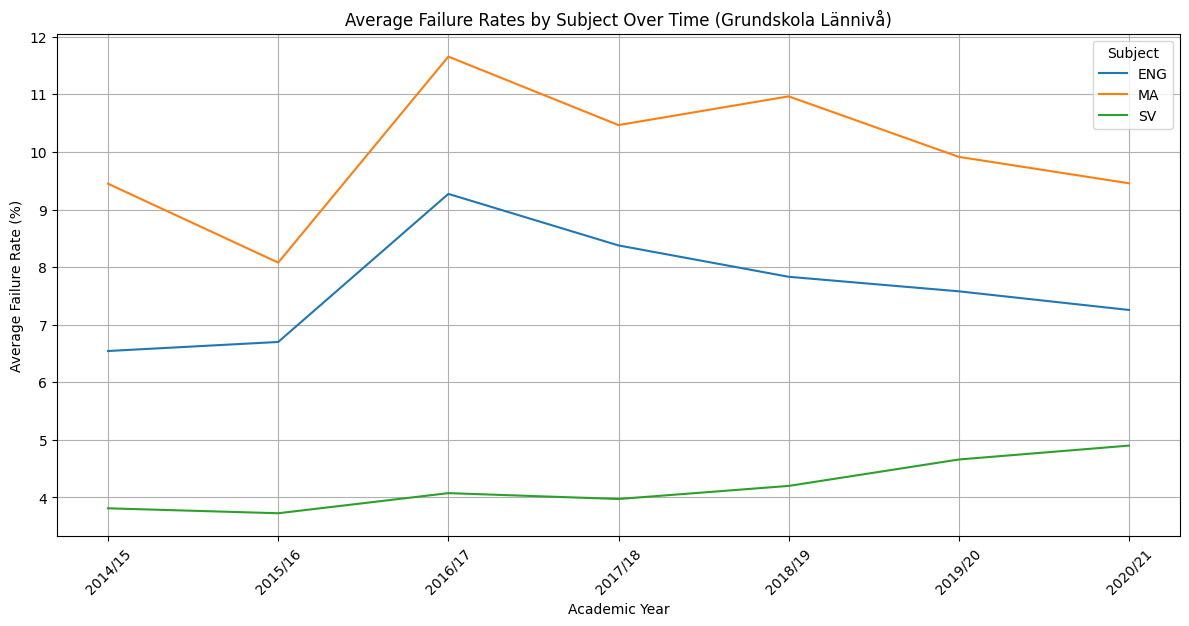

In [19]:
# Step 1: Ensure relevant columns are numeric
failure_columns = ['share_students_F_eng', 'share_students_F_ma', 'share_students_F_sv']
DataFrame_I[failure_columns] = DataFrame_I[failure_columns].apply(pd.to_numeric, errors='coerce')

# Step 2: Group by academic year and calculate mean failure rates
avg_failure_rates = DataFrame_I.groupby('academic_year')[failure_columns].mean().reset_index()

# Step 3: Plot the trends
plt.figure(figsize=(12, 6))
for subject in failure_columns:
    plt.plot(avg_failure_rates['academic_year'], avg_failure_rates[subject], label=subject.replace('share_students_F_', '').upper())

plt.title('Average Failure Rates by Subject Over Time (Grundskola Lännivå)')
plt.xlabel('Academic Year')
plt.ylabel('Average Failure Rate (%)')
plt.legend(title='Subject')
plt.grid(True)
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()